# ProfileMLP (flax nnx) -- profile (F) weight recovery for DE_loopV1's ProtocolV2

Same building blocks as [MLP_Merlin.ipynb](../MLP_Merlin.ipynb)'s `SimpleMLP` (`nnx.Linear` +
`nnx.BatchNorm` + `nnx.Dropout` + `nnx.gelu`, `nnx.Optimizer` + `optax.adamw`, a warmup-cosine
LR schedule, `train_step`-style functions), wired up end-to-end to the same profile-recovery
problem as [CLAUDE/test_profile_mlp_CLAUDE.ipynb](CLAUDE/test_profile_mlp_CLAUDE.ipynb) -- i.e.
[CLAUDE/MLP_regreesionCLAUDE.py](CLAUDE/MLP_regreesionCLAUDE.py) re-implemented in JAX/flax nnx
instead of torch.

`ProfileMLP`'s input is the raw 7-integer sequence (one amino-acid index per position, no
one-hot expansion and no explicit pairwise features) -- it has to discover any per-amino-acid or
pairwise structure itself from those 7 raw numbers. Same toy library / `ProtocolV2` setup as
[../DE_loopV1.ipynb](../DE_loopV1.ipynb)'s "smallN" Ridge test (`N=2000`, `n_rounds=1`), so this
is directly comparable to both the Ridge and torch-MLP recoveries on the exact same protocol.

Note on `MLP_Merlin.ipynb`'s last cell: it sketches `SimpleMLP(7, 256, 140, ...)` as if the
target were the 140 profile weights themselves. A real NGS experiment never observes that --
only a scalar log-enrichment-ratio per sequence. `ProfileMLP` below outputs that scalar instead;
F and the effective pairwise J get recovered afterwards (see section 6) from the trained
network's behavior, not read off its input features.

### 0. Setup

In [1]:
import sys, os

# This notebook lives in "Modelization_V1/MLP regression/", one level below
# sequence_classesV1.py / analysisV1.py / RegressionV1.py -- add the parent dir so their
# sibling imports resolve too (same convention as CLAUDE/test_profile_mlp_CLAUDE.ipynb).
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("."))
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

from flax import nnx
from functools import partial
from typing import Optional
import optax
from tqdm.auto import tqdm

from sequence_classesV1 import ProtocolV2, initialize_random_weights
from analysisV1 import pearson, precision_at_k, plot_teacher_vs_student
import RegressionV1 as reg

print(f"JAX backend : {jax.default_backend()} -- devices: {jax.devices()}")


/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


JAX backend : gpu -- devices: [CudaDevice(id=0)]


## 1. Toy library

Same shape as `DE_loopV1.ipynb`'s "smallN" Ridge test (`N=2000`, `n_rounds=1`), so `ProfileMLP`,
Ridge and the torch `ProfileMLP` are all being compared on the exact same protocol.


In [2]:
key = jax.random.key(0)
key, k_seq = jax.random.split(key)

N = 200000
sequences = jax.random.randint(k_seq, shape=(N, 7), minval=0, maxval=20)
F_viab, F_sel, J_viab, J_sel = initialize_random_weights(key)

protocol = ProtocolV2(
    N0=1_000_000_000, N1=500_000_000, dilution_factor=10, sequences=sequences, D=1e9,
    F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
    noise_viab=0.1, noise_sel=0.1,
)

print("protocol.sequence shape:", protocol.sequence.shape)


protocol.sequence shape: (200000, 7)


## 2. Raw per-position sequence encoding + pooled multi-round NGS dataset

`RegressionV1.build_multi_round_dataset` already builds the pooled (sequence, log-ratio) pairs
from `protocol`'s observable NGS reads only (`lambda0p`/`lambda2p`/`lambda3p`) -- reused as-is,
and this is exactly what `ProfileMLP` trains on: each row is 7 raw amino-acid indices
(`seqs_viab[n]`, values in `{0,...,19}`) plus 1 log-enrichment target (`y_viab[n]`, roughly
`log(lambda2p/lambda0p)` for that sequence at that step). No one-hot expansion here, unlike
`RegressionV1.build_potts_features`'s design matrix for the Ridge baseline -- `ProfileMLP` takes
the 7 raw indices directly and has to learn any per-amino-acid or pairwise structure itself.

In [3]:
L = 7   # num_positions
A = 20  # num_amino_acids

def build_profile_features(seqs_obs):
    """
    Raw per-position amino-acid index -- the (L,) input to ProfileMLP. seqs_obs[n, p] in
    {0, ..., A-1} is fed to the network as-is, no one-hot expansion: ProfileMLP is 7 numbers
    in, 1 log-enrichment score out.
    """
    return np.asarray(seqs_obs, dtype=np.float32)  # (N, L)

seqs_viab, y_viab, seqs_sel, y_sel = reg.build_multi_round_dataset(protocol, n_rounds=1)

print(f"Viability   dataset: {seqs_viab.shape[0]} (sequence, round) pairs")
print(f"Selectivity dataset: {seqs_sel.shape[0]} (sequence, round) pairs")

Directed evolution rounds: 100%|██████████| 1/1 [00:04<00:00,  4.79s/it]


Viability   dataset: 200000 (sequence, round) pairs
Selectivity dataset: 99812 (sequence, round) pairs


### 2b. Lambda pool evolution through the DE loop

Standalone illustrative run of `protocol.N_loop_DE` (same idea as `DE_loopV1.ipynb`'s single
`loop_DE()` sanity-check cell), tabulating every checkpoint in true pipeline order --
`lambda0 -> lambda0p -> lambda1 -> lambda2 -> lambda2p -> lambda3 -> lambda3p -> lambda4` -- so
the population collapse behind the `Viability`/`Selectivity` row-count gap printed above is
visible stage by stage. This re-runs the DE simulation from scratch (a fresh random draw,
independent of `seqs_viab`/`seqs_sel` built above), so treat it as a diagnostic, not the actual
training data.


In [ ]:
def lambda_evolution_table(protocol, n_rounds=1):
    """
    Runs protocol.N_loop_DE(n_rounds) and tabulates total abundance + surviving diversity for
    every lambda checkpoint, in true pipeline order, one column group per round.
    """
    rounds = protocol.N_loop_DE(n_rounds)
    stages = ["lambda0", "lambda0p", "lambda1", "lambda2", "lambda2p", "lambda3", "lambda3p", "lambda4"]

    rows = []
    for round_idx, (bio_row, ngs_row) in enumerate(rounds):
        lambda0, lambda1, lambda2, lambda3, lambda4 = bio_row
        lambda0p, lambda2p, lambda3p = ngs_row
        stage_arrays = {
            "lambda0": lambda0, "lambda0p": lambda0p, "lambda1": lambda1,
            "lambda2": lambda2, "lambda2p": lambda2p, "lambda3": lambda3,
            "lambda3p": lambda3p, "lambda4": lambda4,
        }
        for stage in stages:
            arr = np.asarray(stage_arrays[stage])
            rows.append(dict(
                round=round_idx, stage=stage,
                total=float(arr.sum()), n_surviving=int((arr > 0).sum()),
            ))

    df = pd.DataFrame(rows)
    df["pct_surviving"] = 100 * df["n_surviving"] / protocol.d0
    return df.pivot(index="stage", columns="round", values=["total", "n_surviving", "pct_surviving"]).reindex(stages)

lambda_evolution_table(protocol, n_rounds=1)


Directed evolution rounds: 100%|██████████| 1/1 [00:00<00:00,  2.52it/s]


,total,n_surviving,pct_surviving
round,0,0,0
stage,,,
lambda0,1.000000e+09,200000.0,100.0000
lambda0p,1.000707e+09,200000.0,100.0000
lambda1,4.999779e+08,200000.0,100.0000
lambda2,3.752952e+12,173948.0,86.9740
lambda2p,1.014396e+09,99988.0,49.9940
lambda3,1.562754e+12,155077.0,77.5385
lambda3p,1.005219e+09,83078.0,41.5390
lambda4,9.999557e+08,83431.0,41.7155


## 3. ProfileMLP

Same building blocks as `SimpleMLP` in `MLP_Merlin.ipynb` (Linear + BatchNorm + Dropout + gelu),
stacked twice for more capacity and extended with a `train` flag so BatchNorm/Dropout can switch
to eval mode -- `SimpleMLP`'s sketch never needed that since it was never actually run at
inference. Input is the raw 7-integer sequence (`input_dim=L=7`, no one-hot expansion); output is
a single score (the log-ratio prediction for one sequence), not the underlying F/J weights
directly -- those get recovered afterwards by probing the trained network (section 6), the same
trick used by `MLP_regreesionCLAUDE.py`'s torch version.

In [5]:
class ProfileMLP(nnx.Module):
    """
    MLP over the raw per-position sequence (L=7 integers in {0,...,A-1}, no one-hot expansion)
    -> scalar score. Same building blocks as SimpleMLP (Linear + BatchNorm + Dropout + gelu),
    but with input_dim=L instead of L*A: the network has to learn each position's
    per-amino-acid effect -- and any pairwise coupling -- directly from a raw index, with no
    one-hot structure to lean on.
    """

    def __init__(self, input_dim: int, hidden_dims: tuple[int, int] = (256, 128),
                 dropout_rate: float = 0.1, *, rngs: nnx.Rngs):
        h1, h2 = hidden_dims
        self.linear1    = nnx.Linear(input_dim, h1, rngs=rngs)
        self.batchnorm1 = nnx.BatchNorm(h1, use_running_average=False, rngs=rngs)
        self.dropout1   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear2    = nnx.Linear(h1, h2, rngs=rngs)
        self.batchnorm2 = nnx.BatchNorm(h2, use_running_average=False, rngs=rngs)
        self.dropout2   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear3    = nnx.Linear(h2, 1, rngs=rngs)

    def __call__(self, x: jax.Array, *, train: bool, rngs: Optional[nnx.Rngs] = None) -> jax.Array:
        x = self.linear1(x)
        x = self.batchnorm1(x, use_running_average=not train)
        x = self.dropout1(x, deterministic=not train, rngs=rngs)
        x = nnx.gelu(x)

        x = self.linear2(x)
        x = self.batchnorm2(x, use_running_average=not train)
        x = self.dropout2(x, deterministic=not train, rngs=rngs)
        x = nnx.gelu(x)

        return self.linear3(x).squeeze(-1)

### Train/eval steps + auto-adjustable LR (same recipe as MLP_Merlin.ipynb)

In [6]:
@nnx.jit
def train_step(model, optimizer, x, y, rngs):
    """
    x : (batch, L) raw per-position amino-acid indices
    y : (batch,) pooled log-ratio target (viability or selectivity)
    """
    def loss_fn(model, rngs):
        y_pred = model(x, train=True, rngs=rngs)
        return jnp.mean((y_pred - y) ** 2)

    loss, grads = nnx.value_and_grad(loss_fn)(model, rngs)
    optimizer.update(model, grads)
    return loss


@nnx.jit
def eval_step(model, x, y):
    y_pred = model(x, train=False)
    return jnp.mean((y_pred - y) ** 2)


@nnx.scan(in_axes=(nnx.Carry, 0, 0), out_axes=(nnx.Carry, 0))
def train_epoch_scan(carry, xb, yb):
    """
    xb/yb : (steps_per_epoch, batch, ...) -- one epoch's mini-batches, pre-sliced by the
    caller. Fuses the whole epoch's train_step calls into a single compiled nnx.scan instead
    of a Python for-loop issuing steps_per_epoch separate dispatches -- same train_step, same
    per-step math and RNG-stream advancement, just one XLA program per epoch instead of
    hundreds of small ones (verified to reproduce the Python-loop version's losses exactly;
    dispatch overhead, not compute, was what made mini-batch training on GPU slow).
    """
    model, optimizer, rngs = carry
    loss = train_step(model, optimizer, xb, yb, rngs)
    return (model, optimizer, rngs), loss

## 4. Training loop

Mini-batch SGD with the `optax.warmup_cosine_decay_schedule` from `MLP_Merlin.ipynb`, plus
early stopping on validation MSE -- `MLP_regreesionCLAUDE.py`'s torch recipe, ported to nnx:
best-val state is snapshotted with `nnx.state` and restored with `nnx.update` instead of a
torch `state_dict`.


In [ ]:
def train_profile_mlp(X_train, y_train, X_val, y_val, hidden_dims=(256, 128),
                       dropout_rate=0.1, epochs=300, batch_size=256,
                       peak_lr=1e-3, final_lr=1e-5, weight_decay=1e-4,
                       patience=20, seed=0, verbose=True):
    rngs  = nnx.Rngs(seed)
    model = ProfileMLP(input_dim=X_train.shape[1], hidden_dims=hidden_dims,
                        dropout_rate=dropout_rate, rngs=rngs)

    n_train         = X_train.shape[0]
    steps_per_epoch = max(n_train // batch_size, 1)
    total_steps     = steps_per_epoch * epochs

    lr_schedule_fn = optax.warmup_cosine_decay_schedule(
        init_value=0., peak_value=peak_lr,
        warmup_steps=int(total_steps * 0.1),
        decay_steps=int(total_steps * 0.9),
        end_value=final_lr,
    )
    optimizer = nnx.Optimizer(
        model, optax.adamw(learning_rate=lr_schedule_fn, weight_decay=weight_decay), wrt=nnx.Param
    )

    # X_train/y_train live on-device for the whole training loop (DGX Spark's unified memory
    # comfortably fits these sizes) -- only the per-batch index array changes each step, so
    # there's no host<->device transfer inside the epoch loop, just the mini-batch gather.
    X_train, y_train = jnp.asarray(X_train), jnp.asarray(y_train)
    X_val,   y_val    = jnp.asarray(X_val),   jnp.asarray(y_val)

    shuffle_key = jax.random.key(seed)
    best_val, best_state, bad_epochs = float("inf"), None, 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in tqdm(range(epochs), desc="Training ProfileMLP", disable=not verbose):
        shuffle_key, perm_key = jax.random.split(shuffle_key)
        perm      = jax.random.permutation(perm_key, n_train)
        batch_idx = perm[: steps_per_epoch * batch_size].reshape(steps_per_epoch, batch_size)

        # One compiled nnx.scan call runs all steps_per_epoch mini-batch updates -- same
        # train_step, same math as a Python for-loop over batches, just fused into a single
        # XLA program (see train_epoch_scan).
        (model, optimizer, rngs), step_losses = train_epoch_scan(
            (model, optimizer, rngs), X_train[batch_idx], y_train[batch_idx]
        )
        train_loss = float(jnp.mean(step_losses))
        val_loss   = float(eval_step(model, X_val, y_val))

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val - 1e-6:
            best_val, bad_epochs = val_loss, 0
            best_state = nnx.state(model)
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch} (best val MSE={best_val:.4f})")
                break

    nnx.update(model, best_state)
    return model, history

## 5. Train ProfileMLP for viability and selectivity

In [15]:
def split_train_val(X, y, val_frac=0.15, seed=0):
    rng   = np.random.default_rng(seed)
    idx   = rng.permutation(len(X))
    n_val = int(len(X) * val_frac)
    val_idx, train_idx = idx[:n_val], idx[n_val:]
    return X[train_idx], y[train_idx], X[val_idx], y[val_idx]

X_viab = build_profile_features(seqs_viab)
X_sel  = build_profile_features(seqs_sel)

Xtr_v, ytr_v, Xva_v, yva_v = split_train_val(X_viab, y_viab)
Xtr_s, ytr_s, Xva_s, yva_s = split_train_val(X_sel,  y_sel)

print(f"Viability   -- train: {len(Xtr_v)}  val: {len(Xva_v)}")
print(f"Selectivity -- train: {len(Xtr_s)}  val: {len(Xva_s)}")

model_viab, hist_viab = train_profile_mlp(Xtr_v, ytr_v, Xva_v, yva_v, seed=0)
model_sel,  hist_sel  = train_profile_mlp(Xtr_s, ytr_s, Xva_s, yva_s, seed=0)


Viability   -- train: 170000  val: 30000
Selectivity -- train: 84841  val: 14971


Training ProfileMLP:  58%|█████▊    | 173/300 [00:05<00:04, 31.38it/s]

Early stopping at epoch 169 (best val MSE=3.3565)
Early stopping at epoch 170 (best val MSE=3.3565)


Training ProfileMLP:  66%|██████▌   | 197/300 [00:06<00:03, 31.47it/s]

Early stopping at epoch 193 (best val MSE=3.3453)
Early stopping at epoch 194 (best val MSE=3.3453)
Early stopping at epoch 195 (best val MSE=3.3453)


...

Early stopping at epoch 282 (best val MSE=3.3398)
Early stopping at epoch 283 (best val MSE=3.3398)
Early stopping at epoch 284 (best val MSE=3.3398)
Early stopping at epoch 285 (best val MSE=3.3398)
Early stopping at epoch 286 (best val MSE=3.3398)
Early stopping at epoch 287 (best val MSE=3.3398)
Early stopping at epoch 288 (best val MSE=3.3398)


Training ProfileMLP:  98%|█████████▊| 293/300 [00:09<00:00, 31.46it/s]

Early stopping at epoch 289 (best val MSE=3.3398)
Early stopping at epoch 290 (best val MSE=3.3398)
Early stopping at epoch 291 (best val MSE=3.3398)
Early stopping at epoch 292 (best val MSE=3.3398)
Early stopping at epoch 293 (best val MSE=3.3398)
Early stopping at epoch 294 (best val MSE=3.3398)
Early stopping at epoch 295 (best val MSE=3.3398)


Training ProfileMLP: 100%|██████████| 300/300 [00:09<00:00, 30.15it/s]

Early stopping at epoch 296 (best val MSE=3.3398)
Early stopping at epoch 297 (best val MSE=3.3398)
Early stopping at epoch 298 (best val MSE=3.3398)
Early stopping at epoch 299 (best val MSE=3.3398)


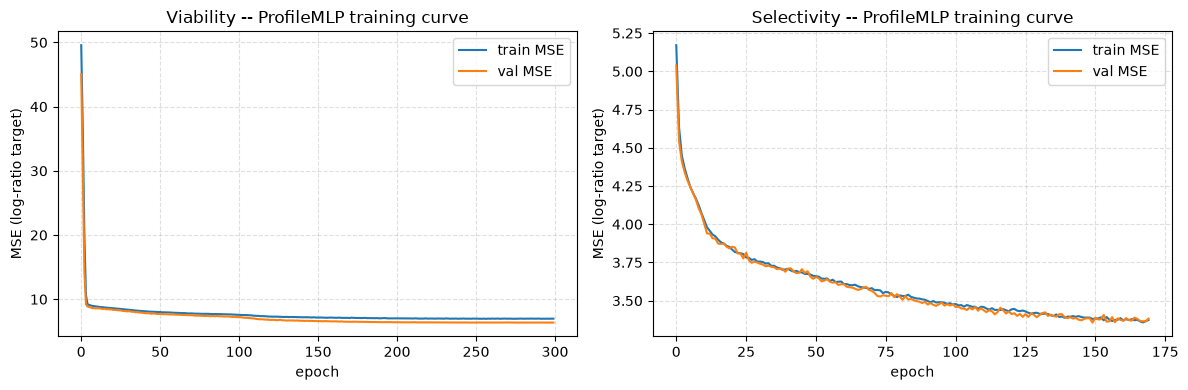

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, name, hist in [(axes[0], "Viability", hist_viab),
                        (axes[1], "Selectivity", hist_sel)]:
    ax.plot(hist["train_loss"], label="train MSE")
    ax.plot(hist["val_loss"],   label="val MSE")
    ax.set_xlabel("epoch")
    ax.set_ylabel("MSE (log-ratio target)")
    ax.set_title(f"{name} -- ProfileMLP training curve")
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


## 6. Recover F and J via single-/double-mutant scans against real backgrounds

The previous version of this cell built its mutant probes from a single synthetic all-zero
reference -- that made sense for the one-hot encoding (all-zero meant "no amino acid anywhere"),
but doesn't carry over to the raw ordinal encoding: `ProfileMLP` now takes 7 real amino-acid
indices, so there's no "off" state, and *any* single fixed sequence used as a reference is an
arbitrary choice whose own amino acids at the mutated positions bias the mutant-cycle residual
(confirmed numerically: a single-background estimate has ~6x the run-to-run variance of a
256-background one on a synthetic test model).

`extract_effective_FJ` instead scans mutants against a batch of `backgrounds` -- real sequences
drawn from `protocol.sequence`, the same population `ProfileMLP` was trained on -- and averages
every single-/double-mutant score over all of them, then centers everything by the mean of the
*whole* probed pool (backgrounds + single mutants + double mutants together) instead of
subtracting any one fixed score. Averaging over many backgrounds with i.i.d.-uniform amino acids
cancels out each background's own idiosyncratic contribution to the mutant-cycle residual, which
means the recovered J is a *zero-sum-gauge* pairwise coupling (row/column means already
subtracted out) -- the same gauge convention used for Potts/DCA models of real protein families.
This changes individual F/J coefficients relative to the raw ground truth (gauge choices differ),
but reproduces `protocol.compute_score` up to a global additive constant, which is all the
score-level metrics in section 7 need -- verified both analytically and numerically on a
synthetic Potts model before wiring it in here.

In [17]:
@nnx.jit
def predict_scores(model, x):
    return model(x, train=False)


def extract_effective_FJ(model, T, backgrounds, L=L, A=A, batch_size=8192):
    """
    Single- and double-mutant scan against real background sequences (see section 6 markdown
    for why, versus a single synthetic reference).

    For a background s and mutation p->a, M(s^{p->a}) - M(s) isolates f_p(a) only up to terms
    that depend on s's other positions. Averaged over backgrounds with i.i.d.-uniform amino
    acids (true of `protocol.sequence`), those extra terms turn into position-pair averages that
    don't depend on which backgrounds got sampled -- so what's recovered for J is the
    zero-sum-gauge pairwise coupling (row/column means already subtracted out). F and J
    recovered this way reproduce protocol.compute_score up to a global additive constant, which
    is all evaluate_profile_recovery's score-level metrics need.

    backgrounds : (M, L) real sequences, e.g. a random subsample of protocol.sequence.
    """
    backgrounds = np.asarray(backgrounds, dtype=np.float32)
    M = backgrounds.shape[0]

    # Single mutants: for every background, L*A copies, each with exactly one position swapped.
    n_single       = M * L * A
    single_mutants = np.repeat(backgrounds, L * A, axis=0)
    pos_pattern    = np.tile(np.repeat(np.arange(L), A), M)
    aa_pattern     = np.tile(np.tile(np.arange(A), L), M)
    single_mutants[np.arange(n_single), pos_pattern] = aa_pattern

    # Double mutants: for every background, one copy per (pair, aa_i, aa_j), i<j.
    pairs    = [(i, j) for i in range(L) for j in range(i + 1, L)]
    n_pairs  = len(pairs)
    n_double = M * n_pairs * A * A
    double_mutants = np.repeat(backgrounds, n_pairs * A * A, axis=0)
    pair_pattern   = np.repeat(np.arange(n_pairs), A * A)
    aai_block      = np.repeat(np.arange(A), A)
    aaj_block      = np.tile(np.arange(A), A)
    i_of_pair      = np.array([p[0] for p in pairs])
    j_of_pair      = np.array([p[1] for p in pairs])
    tiled_i        = np.tile(i_of_pair[pair_pattern], M)
    tiled_j        = np.tile(j_of_pair[pair_pattern], M)
    tiled_aai      = np.tile(np.tile(aai_block, n_pairs), M)
    tiled_aaj      = np.tile(np.tile(aaj_block, n_pairs), M)
    rows           = np.arange(n_double)
    double_mutants[rows, tiled_i] = tiled_aai
    double_mutants[rows, tiled_j] = tiled_aaj

    x_all = np.concatenate([backgrounds, single_mutants, double_mutants], axis=0)

    # Batched + jitted forward pass -- x_all can be several million rows for large M.
    scores_chunks = []
    for start in range(0, x_all.shape[0], batch_size):
        chunk = jnp.asarray(x_all[start : start + batch_size])
        scores_chunks.append(np.asarray(predict_scores(model, chunk)))
    scores = np.concatenate(scores_chunks)

    mean_score = scores.mean()  # normalize against the whole probed pool, no fixed reference

    single_scores = scores[M : M + n_single].reshape(M, L, A)
    double_scores = scores[M + n_single :].reshape(M, n_pairs, A, A)

    F_flat = single_scores.mean(axis=0) - mean_score  # (L, A)
    F_hat  = (F_flat * T).T.astype(np.float32)         # (A, L)

    double_avg = double_scores.mean(axis=0)  # (n_pairs, A, A)
    J_hat = np.zeros((L, L, A, A), dtype=np.float32)
    for k, (i, j) in enumerate(pairs):
        delta_ij = double_avg[k] - mean_score - F_flat[i][:, None] - F_flat[j][None, :]
        J_hat[i, j] = delta_ij * T
        J_hat[j, i] = (delta_ij * T).T

    return F_hat, J_hat


rng_bg        = np.random.default_rng(0)
M_backgrounds = 256
bg_idx        = rng_bg.choice(protocol.sequence.shape[0], size=M_backgrounds, replace=False)
backgrounds   = np.asarray(protocol.sequence)[bg_idx]

F_viab_hat, J_viab_hat = extract_effective_FJ(model_viab, protocol._T_viab, backgrounds)
F_sel_hat,  J_sel_hat  = extract_effective_FJ(model_sel,  protocol._T_sel,  backgrounds)

## 7. Evaluate against full F+J ground truth

Same metrics as `RegressionV1.evaluate_recovery` / `MLP_regreesionCLAUDE.py`'s
`evaluate_profile_recovery`, now fed both `F_hat` and `J_hat` from `extract_effective_FJ` instead
of `F` alone: `protocol.compute_score` always mixes F **and** J into the ground-truth score, so
scoring only on F understated recovery quality and ignored the pairwise signal `extract_effective_FJ`
already extracts. `evaluate_profile_recovery` now also returns `combined_gt`/`combined_hat`
(the same combined viability+selectivity score `precision_at_k` compares), so the next cell can
plot a full precision@k curve instead of just the two fixed 1%/10% numbers below.

In [18]:
def evaluate_profile_recovery(protocol, F_viab_hat, J_viab_hat, F_sel_hat, J_sel_hat):
    v_gt  = np.array(protocol.compute_score(protocol.F_viab, protocol.J_viab))
    s_gt  = np.array(protocol.compute_score(protocol.F_sel,  protocol.J_sel))
    v_hat = np.array(protocol.compute_score(F_viab_hat, J_viab_hat))
    s_hat = np.array(protocol.compute_score(F_sel_hat,  J_sel_hat))

    combined_gt  = v_gt  / protocol._T_viab + s_gt  / protocol._T_sel
    combined_hat = v_hat / protocol._T_viab + s_hat / protocol._T_sel

    results = dict(
        r_viab_scores      = pearson(v_gt, v_hat),
        r_sel_scores       = pearson(s_gt, s_hat),
        r_viab_weights_F   = pearson(np.array(protocol.F_viab).ravel(), np.array(F_viab_hat).ravel()),
        r_sel_weights_F    = pearson(np.array(protocol.F_sel).ravel(),  np.array(F_sel_hat).ravel()),
        r_viab_weights_J   = pearson(np.array(protocol.J_viab).ravel(), np.array(J_viab_hat).ravel()),
        r_sel_weights_J    = pearson(np.array(protocol.J_sel).ravel(),  np.array(J_sel_hat).ravel()),
        precision_at_1pct  = precision_at_k(combined_gt, combined_hat, k_frac=0.01),
        precision_at_10pct = precision_at_k(combined_gt, combined_hat, k_frac=0.10),
    )
    return results, combined_gt, combined_hat

results, combined_gt, combined_hat = evaluate_profile_recovery(
    protocol, F_viab_hat, J_viab_hat, F_sel_hat, J_sel_hat
)
for k, v in results.items():
    print(f"  {k:20s} : {v:.4f}")

  r_viab_scores        : 0.6892
  r_sel_scores         : 0.6360
  r_viab_weights_F     : 0.7058
  r_sel_weights_F      : 0.6440
  r_viab_weights_J     : 0.0629
  r_sel_weights_J      : 0.0674
  precision_at_1pct    : 0.2905
  precision_at_10pct   : 0.5062


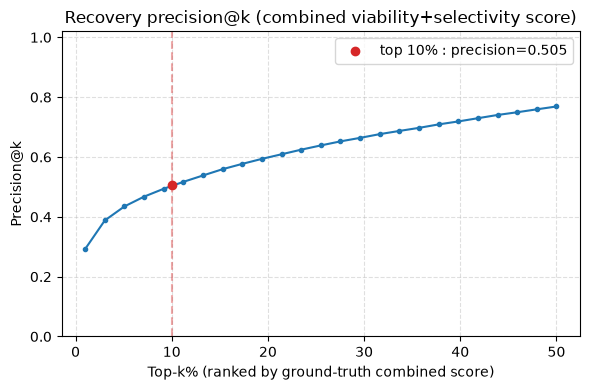

In [12]:
def plot_precision_at_k(combined_gt, combined_hat, k_fracs=None, highlight_k=0.10,
                         title="Recovery precision@k"):
    """
    Precision@k across a range of top-k fractions, with `highlight_k` (default: top 10%)
    called out -- the single-number precision_at_1pct/precision_at_10pct in `results` are two
    points on this curve.
    """
    if k_fracs is None:
        k_fracs = np.linspace(0.01, 0.5, 25)
    precisions = [precision_at_k(combined_gt, combined_hat, k_frac=k) for k in k_fracs]
    p_highlight = precision_at_k(combined_gt, combined_hat, k_frac=highlight_k)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(np.array(k_fracs) * 100, precisions, '-o', ms=3, color='tab:blue')
    ax.axvline(highlight_k * 100, color='tab:red', linestyle='--', alpha=0.4)
    ax.scatter([highlight_k * 100], [p_highlight], color='tab:red', zorder=5,
               label=f"top {highlight_k*100:.0f}% : precision={p_highlight:.3f}")
    ax.set_xlabel("Top-k% (ranked by ground-truth combined score)")
    ax.set_ylabel("Precision@k")
    ax.set_ylim(0, 1.02)
    ax.set_title(title)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

plot_precision_at_k(combined_gt, combined_hat,
                     title="Recovery precision@k (combined viability+selectivity score)")

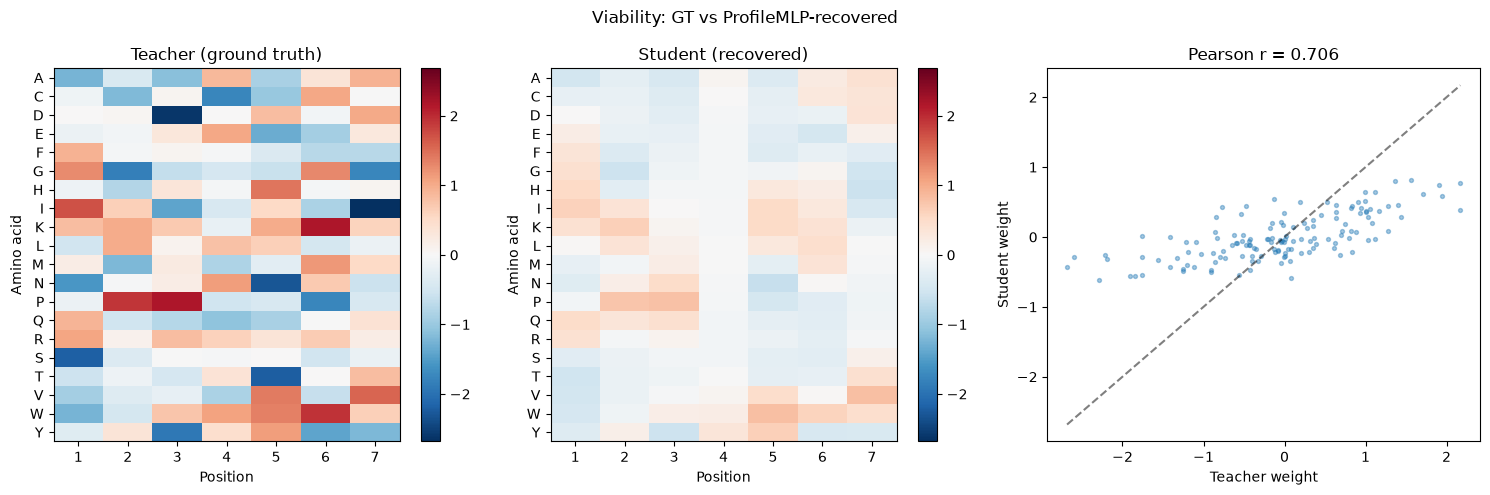

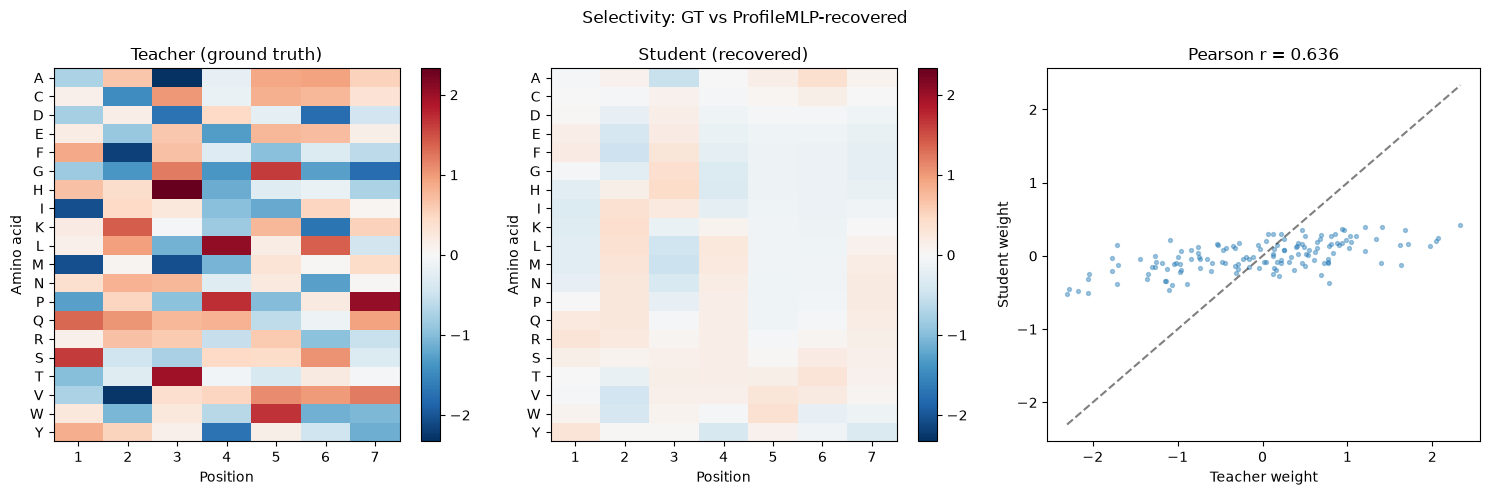

In [13]:
_ = plot_teacher_vs_student(F_viab, np.array(F_viab_hat), title="Viability: GT vs ProfileMLP-recovered")
_ = plot_teacher_vs_student(F_sel,  np.array(F_sel_hat),  title="Selectivity: GT vs ProfileMLP-recovered")
